# 09: KG + LLM Integration

*Does grounding an LLM in knowledge-graph context improve its drug–disease plausibility judgments, and which KG helps most?*

Each stratified drug–disease pair is posed to a local LLM (`llama3.1:8b` via Ollama) under three KG-context conditions:

| Cond | KG block |
|---|---|
| **C0** | none (LLM prior only) |
| **C1** | Layer 1 direct edges (drug/disease neighbours by semantic slot) + Layer 3 attributes |
| **C2** | Layer 2 mechanistic paths `drug → target → disease` + Layer 3 attributes |

KG predicates are mapped to seven canonical slots in `data/kg_slot_maps.yaml`, so the same extraction runs across all 6 KGs. Headline metric: per-(KG, condition) AUROC on the `approved` / `neg_random` / `neg_plausible` strata.

The generation pipeline (pair sampling → extraction → LLM loop) is idempotent — it resumes from `responses_layered.parquet` and is skipped once complete.

**Inputs:** `config.yaml` · `data/kg_slot_maps.yaml` · KG edge files · gold-standard crosswalks · local Ollama (`llama3.1:8b`)
**Outputs:** `results/tables/09_llm_runs/responses_layered.parquet` · `results/figures/09_kg_context_auroc.{pdf,png}`

## Set-up

In [1]:
# Setup
import sys, json, re, gc, time, pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from tqdm import tqdm

BASE = Path('/Users/shil6661/biokgsuite')
if not BASE.exists():
    BASE = Path('/sessions/friendly-focused-edison/mnt/biokgsuite')
sys.path.insert(0, str(BASE / 'src'))
from loading import load_kg, load_config, find_config
from prompting_strategies import STRATEGIES, get_strategy, total_calls_per_cell
from graph_utils import build_graph, build_lookup_maps

config  = load_config(find_config(BASE))
GOLD    = BASE / 'data' / 'gold_standards'
FIGS   = BASE / 'results' / 'figures';   FIGS.mkdir(parents=True, exist_ok=True)
TABLES = BASE / 'results' / 'tables' / '09_llm_runs'
TABLES.mkdir(parents=True, exist_ok=True)


In [2]:
# ── Config ───────────────────────────────────────────────────────────
import yaml as _yaml

# Stratified pair sampling (unchanged from prior design — only headline scope changes).
N_POS_APPROVED  = 50
N_POS_PHASE3    = 50
N_POS_PHASE12   = 50
N_NEG_RANDOM    = 75
N_NEG_PLAUSIBLE = 75
N_POSITIVES = N_POS_APPROVED + N_POS_PHASE3 + N_POS_PHASE12
N_NEGATIVES = N_NEG_RANDOM + N_NEG_PLAUSIBLE

KGS = ['biokg', 'drkg', 'hetionet', 'matrix', 'openbilink', 'primekg']

# 5-condition ablation per the spec.
CONDITIONS = ['C0_no_kg', 'C1_direct', 'C2_paths']   # none / direct edges / all mechanistic bridges (attrs in both)
N_RESEEDS  = 3

# Headline analysis restricted to a balanced 3-way (per spec §1.1). Pairs in
# phase3/phase12 are still generated and queried, but excluded from the
# headline figures and KG ranking. Set to None to use all 5 strata.
HEADLINE_STRATA = ['approved', 'neg_random', 'neg_plausible']

# Layer 2 — bridging paths.
MAX_PATHS_L2 = None  # ALL drug → target → disease bridging paths (no cap)
# Layer 1 — direct edges: relevance-ranked toward the OTHER anchor, total cap.
MAX_L1_KEEP     = 30   # keep top-N most relevant *named* direct edges per side
MAX_L1_PER_SLOT = 20   # (legacy; unused by the relevance ranker)

LLM_TAG     = 'llama3.1:8b'
OLLAMA_URL  = 'http://localhost:11434/api/generate'
TEMPERATURE = 0.0
MAX_TOKENS  = 200  
RANDOM_SEED = 42

STRATEGY    = 'llm_prompt'

PAIRS_FP     = TABLES / 'pairs.parquet'
RESPONSES_FP = TABLES / 'responses_layered.parquet'

# Pilot toggle (set to None for full run).
PILOT_N_PAIRS = 10

# Load semantic slot maps — see data/kg_slot_maps.yaml.
SLOT_MAP_FP = BASE / 'data' / 'kg_slot_maps.yaml'
with SLOT_MAP_FP.open() as f:
    SLOT_MAPS = _yaml.safe_load(f)

CANONICAL_SLOTS = [
    'drug_disease', 'drug_target', 'target_disease',
    'drug_pathway', 'target_pathway', 'disease_phenotype',
    'drug_effect',                       # 7th slot — drug side effects / adverse events
]

n_pairs_full = N_POSITIVES + N_NEGATIVES
n_pairs_used = PILOT_N_PAIRS if PILOT_N_PAIRS else n_pairs_full
n_cells      = n_pairs_used * len(CONDITIONS) * N_RESEEDS * len(KGS)
mode = f'PILOT ({n_pairs_used} pairs)' if PILOT_N_PAIRS else f'FULL ({n_pairs_full} pairs)'
print(f'{mode}  ·  {len(KGS)} KGs × {len(CONDITIONS)} conditions × '
      f'{N_RESEEDS} reseeds = {n_cells:,} LLM calls')
print(f'Slot map: {SLOT_MAP_FP.name}  ·  KGs in map: {sorted(SLOT_MAPS.keys())}')


# ── RUN MODE (added) ───────────────────────────────────────────────────
# Flip scope without touching anything else below.
#   'pilot'       — 10-pair smoke test (original).
#   'local_desat' — quick de-saturation run on a laptop via local Ollama:
#                   ~150 balanced pairs (breaks the C0=1.0 ceiling), 1 reseed,
#                   good-coverage KGs only. Drops hetionet (low disease
#                   coverage) and matrix (too big to load on a laptop) — add
#                   them back on HPC.
#   'full'        — paper-grade: all pairs, 3 reseeds, all 6 KGs (HPC).
RUN_MODE = 'full'

if RUN_MODE == 'pilot':
    PILOT_N_PAIRS, N_RESEEDS, RUN_KGS = 10, 1, list(KGS)
elif RUN_MODE == 'local_desat':
    PILOT_N_PAIRS, N_RESEEDS = 150, 1
    RUN_KGS = ['primekg', 'openbilink', 'drkg', 'biokg']
elif RUN_MODE == 'full':
    PILOT_N_PAIRS, N_RESEEDS, RUN_KGS = None, 1, list(KGS)   # 300 pairs, all 6 KGs, no reseeds
else:
    raise ValueError(f'unknown RUN_MODE {RUN_MODE!r}')

print(f'RUN_MODE={RUN_MODE}  pairs={PILOT_N_PAIRS or n_pairs_full}  '
      f'reseeds={N_RESEEDS}  KGs={RUN_KGS}')


PILOT (10 pairs)  ·  6 KGs × 3 conditions × 3 reseeds = 540 LLM calls
Slot map: kg_slot_maps.yaml  ·  KGs in map: ['biokg', 'drkg', 'hetionet', 'matrix', 'openbilink', 'primekg']
RUN_MODE=full  pairs=300  reseeds=1  KGs=['biokg', 'drkg', 'hetionet', 'matrix', 'openbilink', 'primekg']


## 1 · Pair sampling

In [3]:
if PAIRS_FP.exists():
    pairs = pd.read_parquet(PAIRS_FP)
else:
    ind = pd.read_csv(GOLD / 'opentargets_drug_indications.csv')
    ind['drug_id'] = ind['drugbank_id']
    def _norm_mondo(v):
        s = str(v).strip().replace('MONDO:', '')
        try:    return f'MONDO:{int(float(s))}' if s not in ('', 'nan') else None
        except (ValueError, OverflowError): return None
    ind['disease_id'] = ind['mondo_id'].fillna(ind['mondo_id_mapped']).map(_norm_mondo)
    ind = ind.dropna(subset=['drug_id', 'disease_id', 'drug_name', 'disease_name'])
    rng = np.random.default_rng(RANDOM_SEED)

    # ── stratified positives ────────────────────────────────────────────
    pool_approved = ind[ind['is_approved'] == True]
    pool_phase3   = ind[(ind['max_phase'] == 3) & (ind['is_approved'] != True)]
    pool_phase12  = ind[ind['max_phase'].isin([1.0, 2.0])]
    print(f'OT pools — approved: {len(pool_approved):,}  phase3: {len(pool_phase3):,}  phase12: {len(pool_phase12):,}')

    pos_a = pool_approved.sample(n=N_POS_APPROVED, random_state=RANDOM_SEED).assign(stratum='approved', label=1)
    pos_3 = pool_phase3.sample  (n=N_POS_PHASE3,   random_state=RANDOM_SEED+1).assign(stratum='phase3',   label=1)
    pos_1 = pool_phase12.sample (n=N_POS_PHASE12,  random_state=RANDOM_SEED+2).assign(stratum='phase12',  label=1)
    pos = pd.concat([pos_a, pos_3, pos_1], ignore_index=True)

    # ── negatives: random + plausible ───────────────────────────────────
    drug_to_dis = ind.groupby('drug_id')['disease_id'].apply(set).to_dict()
    all_diseases = ind[['disease_id', 'disease_name']].drop_duplicates()
    approved_pool_diseases = pool_approved[['disease_id', 'disease_name']].drop_duplicates()  # for plausible negs
    drug_pool = pos[['drug_id', 'drug_name']].drop_duplicates().to_dict('records')

    def _draw_negs(n_target, disease_pool, neg_type):
        rows = []
        for _ in range(n_target * 8):           # over-sample, dedupe via the set membership check
            d = drug_pool[int(rng.integers(len(drug_pool)))]
            x = disease_pool.sample(n=1, random_state=int(rng.integers(2**31))).iloc[0]
            if x['disease_id'] in drug_to_dis.get(d['drug_id'], set()): continue
            rows.append({'drug_id': d['drug_id'], 'drug_name': d['drug_name'],
                         'disease_id': x['disease_id'], 'disease_name': x['disease_name'],
                         'stratum': neg_type, 'label': 0})
            if len(rows) >= n_target: break
        return rows

    neg_rand = _draw_negs(N_NEG_RANDOM,   all_diseases,            'neg_random')
    neg_plaus= _draw_negs(N_NEG_PLAUSIBLE, approved_pool_diseases, 'neg_plausible')
    neg = pd.DataFrame(neg_rand + neg_plaus)

    pairs = pd.concat([pos[['drug_id','drug_name','disease_id','disease_name','stratum','label']], neg],
                      ignore_index=True)
    pairs['pair_idx'] = range(len(pairs))
    pairs.to_parquet(PAIRS_FP, index=False)

print(f'{len(pairs)} pairs total')
print(pairs.groupby(['stratum', 'label']).size().rename('n'))
pairs.head()


300 pairs total
stratum        label
approved       1        50
neg_plausible  0        75
neg_random     0        75
phase12        1        50
phase3         1        50
Name: n, dtype: int64


,drug_id,drug_name,disease_id,disease_name,stratum,label,pair_idx
0,DB01248,DOCETAXEL ANHYDROUS,MONDO:4950,gastric carcinoma,approved,1,0
1,DB00877,SIROLIMUS,MONDO:1734,tuberous sclerosis,approved,1,1
2,DB08897,ACLIDINIUM,MONDO:4849,emphysema,approved,1,2
3,DB01104,SERTRALINE,MONDO:5146,post-traumatic stress disorder,approved,1,3
4,DB00625,EFAVIRENZ,MONDO:21094,immunodeficiency disease,approved,1,4


## 2 · ID crosswalks

In [4]:
drugbank  = pd.read_csv(GOLD / 'drugbank_drugs.csv', low_memory=False)
do        = pd.read_csv(GOLD / 'do_diseases.csv')
mesh_doid = pd.read_csv(GOLD / 'mesh_to_doid.csv', on_bad_lines='skip')
uniprot   = pd.read_csv(GOLD / 'uniprot_genesproteins.csv', low_memory=False)
xref      = pd.read_csv(GOLD / 'drugbank_xref.csv')
sssom     = pd.read_csv(GOLD / 'mondo.sssom.tsv', sep='\t', comment='#')
sssom     = sssom[sssom['predicate_id'] == 'skos:exactMatch']

# MONDO ↔ DOID  (many-to-many)
_do = do.dropna(subset=['mondo_id', 'doid']).copy()
_do['m'] = _do['mondo_id'].str.replace('MONDO:', '', regex=False).str.lstrip('0').replace({'': '0'})
_do['d'] = _do['doid'].str.replace('DOID:', '', regex=False).str.lstrip('0').replace({'': '0'})
mondo_to_doid_all = defaultdict(set); doid_to_mondo_all = defaultdict(set)
for _, r in _do.iterrows():
    mondo_to_doid_all[r['m']].add(r['d']); doid_to_mondo_all[r['d']].add(r['m'])

# MESH ↔ DOID  (DO source wins over MONDO source)
mesh_doid['mesh_clean'] = mesh_doid['mesh_id'].str.replace(r'\s*\{.*\}', '', regex=True).str.strip()
_mh = (mesh_doid.assign(src_rank=mesh_doid['source'].map({'DO': 0, 'MONDO': 1}).fillna(2))
                .sort_values('src_rank').drop_duplicates('mesh_clean', keep='first'))
mesh_to_doid = {r['mesh_clean']: (r['doid'].replace('DOID:', '').lstrip('0') or '0')
                for _, r in _mh.iterrows() if pd.notna(r['doid'])}
doid_to_mesh = defaultdict(set)
for m, d in mesh_to_doid.items():
    if m.startswith('MESH:'): doid_to_mesh[d].add(m)

# OpenBioLink PubChem → DrugBank (from project crosswalk file)
_obl_db_to_pc = defaultdict(set); _obl_pc_to_db = {}
pc_path = BASE / 'data' / 'openbilink' / 'pubchem_to_drugbank.csv'
if pc_path.exists():
    _pc = pd.read_csv(pc_path)
    for pc, db in zip(_pc.iloc[:, 0].astype(str), _pc.iloc[:, 1].astype(str)):
        if db.startswith('DB'): _obl_pc_to_db[pc] = db; _obl_db_to_pc[db].add(pc)

# DrugBank cross-namespace xref (CID, ChEMBL, ChEBI, RxCUI, …)
drug_equiv = defaultdict(set)
for db, ns, eid in zip(xref.drugbank_id.astype(str), xref.namespace.astype(str), xref.external_id.astype(str)):
    drug_equiv[db].update({f'{ns}:{eid}', eid})
    if ns == 'PUBCHEM.COMPOUND': drug_equiv[db].update({f'CID:{eid}', f'pubchem.compound:{eid}'})

# SSSOM disease equivalents
_eq = defaultdict(set)
for s, o in zip(sssom['subject_id'], sssom['object_id']):
    _eq[s].add(o); _eq[o].add(s)
disease_equiv = defaultdict(set)
for k, vs in _eq.items():
    s = set(vs)
    for v in vs: s |= _eq.get(v, set())
    s.discard(k); disease_equiv[k] = s

print(f'mondo_to_doid_all: {len(mondo_to_doid_all):,}  |  mesh_to_doid: {len(mesh_to_doid):,}  '
      f'|  drug_equiv: {len(drug_equiv):,}  |  sssom: {len(disease_equiv):,}')


mondo_to_doid_all: 11,767  |  mesh_to_doid: 4,913  |  drug_equiv: 17,687  |  sssom: 133,771


## 3 · Inverse resolvers

In [5]:
_BARE_MESH = re.compile(r'^[DC]\d+$')

def _variants(cands):
    out = set(cands)
    for c in list(cands):
        if not isinstance(c, str): continue
        if ':' in c:
            ns, _, rest = c.partition(':')
            out.update({c.replace(':', '_', 1), f'{ns.upper()}:{rest}', f'{ns.lower()}:{rest}', rest})
            try:
                stripped = str(int(rest))
                if stripped != rest: out.add(stripped)
            except (ValueError, TypeError): pass
        if '_' in c and ':' not in c:
            out.add(c.replace('_', ':', 1))
    return out

def to_kg_drug_ids(db_id, kg_name):
    s = str(db_id).strip()
    cands = {s} | drug_equiv.get(s, set())
    if kg_name == 'openbilink':
        for pc in _obl_db_to_pc.get(s, set()):
            cands.update({f'PUBCHEM.COMPOUND:{pc}', f'PUBCHEM.COMPOUND_{pc}', pc})
    return _variants(cands)

def to_kg_disease_ids(disease_id, kg_name):
    s = str(disease_id).strip()
    scheme = config['knowledge_graphs'][kg_name].get('disease_id_scheme', 'doid')

    # Normalise input to a bare MONDO numeric
    if   s.startswith('MONDO:'):  mondo = s.replace('MONDO:', '').lstrip('0') or '0'
    elif s.startswith('DOID:'):   mondo = (sorted(doid_to_mondo_all.get(s.replace('DOID:', '').lstrip('0') or '0', ['?']))[0])
    elif _BARE_MESH.match(s):     d = mesh_to_doid.get(f'MESH:{s}'); mondo = sorted(doid_to_mondo_all.get(d, ['?']))[0] if d else '?'
    else:                         mondo = s.lstrip('0') or '0'

    cands = set()
    if scheme == 'mondo':
        cands.update({mondo, mondo.zfill(7), f'MONDO:{mondo}'})
    elif scheme == 'doid':
        for d in mondo_to_doid_all.get(mondo, set()):
            cands.update({d, f'DOID:{d}'})
    elif scheme == 'doid_mesh':
        for d in mondo_to_doid_all.get(mondo, set()):
            cands.update({d, f'DOID:{d}'}); cands |= doid_to_mesh.get(d, set())
    elif scheme == 'mesh':
        for d in mondo_to_doid_all.get(mondo, set()):
            for m in doid_to_mesh.get(d, set()): cands.update({m, m.split(':', 1)[-1]})

    # SSSOM expansion
    for c in list(cands) + [f'MONDO:{mondo}']:
        cands |= disease_equiv.get(c, set())
    return _variants(cands)


## 4 · Slot-aware layered extraction

In [6]:
# Slot-aware edge index + Layer 1/2/3 extractors + condition serializers.

# Readable relation phrases per canonical slot (human-legible context).
SLOT_VERB = {
    'drug_disease':      'is indicated for',
    'drug_target':       'targets',
    'target_disease':    'is associated with',
    'drug_pathway':      'acts in pathway',
    'target_pathway':    'participates in pathway',
    'disease_phenotype': 'has phenotype',
    'drug_effect':       'can cause',
}

def build_slot_aware_index(kg_df, kg_name):
    """Bidirectional edge index keyed by node_idx → [(neighbour, predicate, slot)].
    `slot` is the canonical slot for the predicate per SLOT_MAPS[kg_name], or
    None if unmapped. None-slot edges are kept in the index (for total-degree
    computations) but Layer 1/2 selectively filter on slot."""
    slot_map = SLOT_MAPS.get(kg_name, {})
    rel_to_slot = {}
    for slot, rels in slot_map.items():
        for rel in (rels or []):
            rel_to_slot[str(rel)] = slot
    ix = defaultdict(list)
    for x, y, r in zip(kg_df['x_index'].values, kg_df['y_index'].values,
                       kg_df['relation'].values):
        u, v, rs = int(x), int(y), str(r)
        slot = rel_to_slot.get(rs)
        ix[u].append((v, rs, slot))
        ix[v].append((u, rs, slot))
    return ix


def layer1_edges(anchor_idx, edge_index, type_map, drug_t, disease_t,
                  other_anchor_idx=None, bridge_nodes=None, name_map=None,
                  top_n=None):
    """Direct edges incident to anchor_idx, RELEVANCE-RANKED toward the other
    anchor and capped to the top `top_n` overall (not per slot).

    Relevance: 2 = neighbour IS the other anchor (a direct drug-disease edge);
    1 = neighbour bridges to the other anchor (on a drug->target->disease path);
    0 = otherwise. Ties broken by specificity (lower neighbour degree first).
    If `name_map` is given, neighbours with no readable name are skipped so the
    kept top-N are all legible.

    Returns (edges_by_slot, total_by_slot)."""
    if top_n is None:
        top_n = MAX_L1_KEEP
    bridge_nodes = bridge_nodes or set()
    by_slot = defaultdict(list)
    if anchor_idx is None:
        return dict(by_slot), {s: 0 for s in CANONICAL_SLOTS}

    anchor_type = type_map.get(anchor_idx)
    cand, totals = [], defaultdict(int)
    for v, rel, slot in edge_index.get(anchor_idx, []):
        if slot is None:
            continue
        v_type = type_map.get(v)
        if anchor_type == drug_t and v_type == drug_t:
            continue
        if anchor_type == disease_t and v_type == disease_t and slot != 'disease_phenotype':
            continue
        if name_map is not None and name_map.get(v) is None:
            continue
        totals[slot] += 1
        relevance = (2 if (other_anchor_idx is not None and v == other_anchor_idx)
                     else 1 if v in bridge_nodes else 0)
        cand.append((relevance, -len(edge_index.get(v, [])),
                     slot, anchor_idx, v, rel, v_type))

    cand.sort(key=lambda c: (c[0], c[1]), reverse=True)
    out_by_slot = defaultdict(list)
    for _r, _nd, slot, h, t, r, vt in cand[:top_n]:
        out_by_slot[slot].append((h, t, r, vt))
    return {s: out_by_slot.get(s, []) for s in CANONICAL_SLOTS}, dict(totals)


def layer2_paths(drug_idx, disease_idx, edge_index, max_paths=None):
    """Find top-K (drug → target → disease) bridging paths.

    A bridging target is a node N such that:
      drug → N via `drug_target` slot, AND
      N → disease via `target_disease` slot.

    Sorted by N's total degree ASCENDING (lower degree = more specific).
    Returns list of (drug_idx, target_idx, drug_rel, disease_idx, target_rel, target_degree).
    """
    if max_paths is None:
        max_paths = MAX_PATHS_L2
    if drug_idx is None or disease_idx is None:
        return []

    drug_to_target = {}     # target_idx → drug→target predicate
    for v, rel, slot in edge_index.get(drug_idx, []):
        if slot == 'drug_target':
            drug_to_target.setdefault(v, rel)

    target_to_disease = {}  # target_idx → target→disease predicate
    for v, rel, slot in edge_index.get(disease_idx, []):
        if slot == 'target_disease':
            target_to_disease.setdefault(v, rel)

    shared = set(drug_to_target) & set(target_to_disease)
    ranked = sorted(shared, key=lambda n: len(edge_index.get(n, [])))
    out = []
    for n in ranked[:max_paths]:
        out.append((drug_idx, n, drug_to_target[n],
                    disease_idx, target_to_disease[n],
                    len(edge_index.get(n, []))))
    return out


def has_direct_drug_disease_edge(drug_idx, disease_idx, edge_index):
    """Whether the KG contains a direct `drug_disease`-slot edge between this pair."""
    if drug_idx is None or disease_idx is None:
        return False
    for v, rel, slot in edge_index.get(drug_idx, []):
        if v == disease_idx and slot == 'drug_disease':
            return True
    return False


def layer3_attrs(node_indices, nodes_df, type_map):
    """Compact attribute lookup for nodes appearing in L1/L2.

    Returns dict[node_idx → (name, type_str)]. Keep it minimal — the spec
    flags that verbose descriptions are token waste.
    """
    if not node_indices:
        return {}
    sub = nodes_df[nodes_df['idx'].isin(list(node_indices))]
    return {int(r['idx']): (str(r.get('name', '')), str(r.get('type', '')))
            for _, r in sub.iterrows()}


# ── Serialization: --[rel]--> arrow format ────────────────────────────────

def _arrow(name_map, src_idx, rel, dst_idx):
    return (f'{name_map.get(src_idx, src_idx)} '
            f'--[{rel}]--> '
            f'{name_map.get(dst_idx, dst_idx)}')


def _section_direct(drug_name, drug_in_kg, drug_l1, disease_name, disease_in_kg,
                     disease_l1, name_map, drug_side_only=False):
    """### Direct associations — drug-side and (optionally) disease-side edges
    formatted as one arrow per line, grouped by slot."""
    lines = ['### Direct associations']
    # Drug side
    if drug_in_kg:
        any_drug = False
        for slot in CANONICAL_SLOTS:
            for h, t, rel, _ in drug_l1.get(slot, []):
                if name_map.get(t) is None:
                    continue
                lines.append(f'- {_arrow(name_map, h, SLOT_VERB.get(slot, rel), t)}')
                any_drug = True
        if not any_drug:
            lines.append(f'- (no slot-typed edges for {drug_name})')
    else:
        lines.append(f'- (This KG does not contain {drug_name}.)')
    # Disease side (skip for C4 drug-only)
    if not drug_side_only:
        lines.append('')
        if disease_in_kg:
            any_dis = False
            for slot in CANONICAL_SLOTS:
                for h, t, rel, _ in disease_l1.get(slot, []):
                    if name_map.get(t) is None:
                        continue
                    lines.append(f'- {_arrow(name_map, h, SLOT_VERB.get(slot, rel), t)}')
                    any_dis = True
            if not any_dis:
                lines.append(f'- (no slot-typed edges for {disease_name})')
        else:
            lines.append(f'- (This KG does not contain {disease_name}.)')
    return '\n'.join(lines)


def _section_paths(drug_name, disease_name, paths, name_map):
    """### Mechanistic paths."""
    lines = [f'### Mechanistic paths ({drug_name} → target → {disease_name})']
    if not paths:
        lines.append('(no shared drug-target / disease-gene bridging nodes)')
        return '\n'.join(lines)
    _k = 0
    for (d, n, d_rel, x, x_rel, _deg) in paths:
        if name_map.get(n) is None:
            continue
        _k += 1
        lines.append(f'{_k}. {name_map.get(d, d)} '
                     f'--[{SLOT_VERB.get("drug_target", d_rel)}]--> {name_map.get(n, n)} '
                     f'--[{SLOT_VERB.get("target_disease", x_rel)}]--> {name_map.get(x, x)}')
    if _k == 0:
        lines.append('(no named bridging nodes)')
    return '\n'.join(lines)


def _section_attrs(attrs, name_map):
    """### Entity notes — one line per named node."""
    if not attrs:
        return ''
    lines = ['### Entity notes']
    seen = set()
    for idx, (name, ntype) in attrs.items():
        nm = name_map.get(idx)
        if not nm or nm in seen:
            continue
        seen.add(nm)
        lines.append(f'- {nm}: {ntype}')
    return '\n'.join(lines) if len(lines) > 1 else ''


def build_kg_block(kg_name, condition, drug_name, drug_in_kg, drug_l1,
                    disease_name, disease_in_kg, disease_l1, paths, attrs,
                    name_map):
    """Assemble the kg_block for one condition. C0 returns empty (the
    LLMPrompt strategy will emit 'No knowledge graph context provided.')."""
    if condition == 'C0_no_kg':
        return ''
    parts = [f'## Knowledge Graph: {kg_name}']
    if condition == 'C2_paths':
        parts.append(_section_paths(drug_name, disease_name, paths, name_map))
    elif condition == 'C4_drug_only':
        parts.append(_section_direct(drug_name, drug_in_kg, drug_l1,
                                      disease_name, disease_in_kg, disease_l1,
                                      name_map, drug_side_only=True))
    else:  # C1_direct (and legacy C3_full): drug + disease direct edges
        parts.append(_section_direct(drug_name, drug_in_kg, drug_l1,
                                      disease_name, disease_in_kg, disease_l1,
                                      name_map))
        if condition == 'C3_full':
            parts.append(_section_paths(drug_name, disease_name, paths, name_map))
    # Entity attributes (full context) included on every KG condition.
    # Entity notes scoped to the nodes THIS condition actually shows
    # (so C2_paths doesn't leak C1_direct's neighbours via the notes).
    if condition == 'C2_paths':
        _shown = {i for (dd, nn, _a, xx, _b, _c) in paths for i in (dd, nn, xx)}
    elif condition == 'C4_drug_only':
        _shown = {i for se in drug_l1.values() for (h, t, _r, _vt) in se for i in (h, t)}
    else:
        _shown = {i for sl in (drug_l1, disease_l1) for se in sl.values()
                  for (h, t, _r, _vt) in se for i in (h, t)}
        if condition == 'C3_full':
            _shown |= {i for (dd, nn, _a, xx, _b, _c) in paths for i in (dd, nn, xx)}
    attrs_section = _section_attrs({i: v for i, v in attrs.items() if i in _shown}, name_map)
    if attrs_section:
        parts.append(attrs_section)
    return '\n\n'.join(parts)

    parts.append(_section_direct(drug_name, drug_in_kg, drug_l1,
                                  disease_name, disease_in_kg, disease_l1,
                                  name_map))
    if condition in ('C2_paths', 'C3_full'):
        parts.append(_section_paths(drug_name, disease_name, paths, name_map))
    if condition == 'C3_full':
        attrs_section = _section_attrs(attrs, name_map)
        if attrs_section:
            parts.append(attrs_section)
    return '\n\n'.join(parts)

In [7]:
# Human-readable name resolution
import re as _re
KEEP_ONLY_NAMED = True   # drop neighbours that do not resolve to a real name

DRUG_NAME = {str(i).upper(): str(n) for i, n in
             zip(drugbank['drugbank_id'], drugbank['name']) if pd.notna(n)}

GENE_NAME = {}
for _entry, _gids, _gnames, _pnames in zip(
        uniprot['Entry'], uniprot['GeneID'], uniprot['Gene Names'], uniprot['Protein names']):
    _sym = None
    if pd.notna(_gnames) and str(_gnames).strip():
        _sym = str(_gnames).split()[0]
    elif pd.notna(_pnames):
        _sym = str(_pnames)
    if not _sym:
        continue
    if pd.notna(_entry):
        GENE_NAME[str(_entry)] = _sym
    if pd.notna(_gids):
        for _g in str(_gids).replace(';', ' ').split():
            if _g:
                GENE_NAME[_g] = _sym

# Keep DOID and MONDO in SEPARATE namespaces
DOID_NAME, MONDO_NAME = {}, {}
for _doid, _mondo, _nm in zip(do['doid'], do['mondo_id'], do['mondo_name']):
    if pd.isna(_nm):
        continue
    if pd.notna(_doid):
        DOID_NAME[str(_doid).replace('DOID:', '').lstrip('0') or '0'] = str(_nm)
    if pd.notna(_mondo):
        MONDO_NAME[str(_mondo).replace('MONDO:', '').lstrip('0') or '0'] = str(_nm)

MESH_NAME = {}
try:
    for _mk, _dn in mesh_to_doid.items():
        _mm = _re.search(r'([CD]\d+)', str(_mk))
        _nm = DOID_NAME.get(str(_dn).replace('DOID:', '').lstrip('0') or '0')
        if _mm and _nm:
            MESH_NAME[_mm.group(1).upper()] = _nm
except Exception:
    pass
_MESH_RE = _re.compile(r'MESH[:_]?([CD]\d+)', _re.I)

_DB_RE     = _re.compile(r'(DB\d{4,})', _re.I)
_DOID_RE   = _re.compile(r'DOID[:_]?0*(\d+)', _re.I)
_MONDO_RE  = _re.compile(r'MONDO[:_]?0*(\d+)', _re.I)
_UNIPROT_RE= _re.compile(r'\b([A-NR-Z][0-9][A-Z0-9]{3}[0-9])\b')
_ENTREZ_RE = _re.compile(r'(?:^|[:_])(\d{2,})$')

def _is_human_name(name, raw):
    s = str(name or '')
    if not s or s == str(raw):
        return False
    # human names have a 3+ letter run and aren't pure ID strings
    return bool(_re.search(r'[A-Za-z]{3,}', s)) and not _re.fullmatch(r'[A-Z0-9:_.\-]+', s)

def _lookup_external(raw, ntype):
    r = str(raw); nt = str(ntype or '').lower()
    try:
        m = _DB_RE.search(r)
        if m and DRUG_NAME.get(m.group(1).upper()):
            return DRUG_NAME[m.group(1).upper()]
        m = _DOID_RE.search(r)
        if m and DOID_NAME.get(m.group(1).lstrip('0') or '0'):
            return DOID_NAME[m.group(1).lstrip('0') or '0']
        m = _MONDO_RE.search(r)
        if m and MONDO_NAME.get(m.group(1).lstrip('0') or '0'):
            return MONDO_NAME[m.group(1).lstrip('0') or '0']
        m = _MESH_RE.search(r)
        if m and MESH_NAME.get(m.group(1).upper()):
            return MESH_NAME[m.group(1).upper()]
        if any(k in nt for k in ('gene', 'protein', 'target')) or True:
            m = _UNIPROT_RE.search(r)
            if m and m.group(1) in GENE_NAME:
                return GENE_NAME[m.group(1)]
            m = _ENTREZ_RE.search(r)
            if m and m.group(1) in GENE_NAME:
                return GENE_NAME[m.group(1)]
    except Exception:
        return None
    return None

def build_readable_name_map(nodes_df, kg_name, base_name_map):
    """idx -> best human-readable label, using native name, then gold tables,
    then a clean typed fallback (e.g. 'protein:P23219'). Never returns a bare
    integer index."""
    names = nodes_df['name'].astype(str) if 'name' in nodes_df.columns \
            else nodes_df['id'].astype(str)
    out = {}
    for idx, raw, name, typ in zip(nodes_df['idx'].astype(int),
                                   nodes_df['id'].astype(str), names,
                                   nodes_df['type'].astype(str)):
        if _is_human_name(name, raw):
            out[idx] = name; continue
        ext = _lookup_external(raw, typ)
        if ext:
            out[idx] = ext; continue
        if KEEP_ONLY_NAMED:
            out[idx] = None
        else:
            clean = raw.split('::', 1)[-1]
            out[idx] = f'{typ}:{clean}' if typ and typ.lower() not in clean.lower() else clean
    return out

print(f'name tables: drugs={len(DRUG_NAME):,}  genes={len(GENE_NAME):,}  '
      f'diseases={len(DOID_NAME) + len(MONDO_NAME) + len(MESH_NAME):,} '
      f'(DOID {len(DOID_NAME):,} · MONDO {len(MONDO_NAME):,} · MESH {len(MESH_NAME):,})')


name tables: drugs=19,830  genes=39,707  diseases=28,593 (DOID 11,932 · MONDO 11,767 · MESH 4,894)


## 5 · LLM client

In [8]:
def ollama_query(prompt, seed=0, temperature=None, max_tokens=None, format=None):
    """POST one prompt to Ollama. `format='json'` triggers JSON-mode decoding."""
    options = {
        'temperature': TEMPERATURE if temperature is None else temperature,
        'num_predict': MAX_TOKENS  if max_tokens  is None else max_tokens,
        'seed': int(seed),
    }
    payload = {'model': LLM_TAG, 'prompt': prompt, 'stream': False, 'options': options}
    if format is not None:
        payload['format'] = format
    try:
        r = requests.post(OLLAMA_URL, json=payload, timeout=120)
        r.raise_for_status()
        return {'response': r.json().get('response', ''), 'error': None}
    except Exception as e:
        return {'response': '', 'error': str(e)}

tags = {m['name'] for m in
        requests.get('http://localhost:11434/api/tags', timeout=3).json().get('models', [])}
print(f'Ollama up — {LLM_TAG} {"✓" if LLM_TAG in tags else "✗ MISSING"}')

Ollama up — llama3.1:8b ✓


## 6 · Main loop (idempotent — resumes/skips if already run)

In [9]:
# Idempotency guard: skip the expensive KG-load + extraction + LLM loop when
# responses_layered.parquet already exists. Set FORCE_LLM_RERUN = True to
# (re)run - the inner per-cell `done` check still resumes a partial run.
FORCE_LLM_RERUN = globals().get('FORCE_LLM_RERUN', False)
if not FORCE_LLM_RERUN and RESPONSES_FP.exists():
    print(f'{RESPONSES_FP.name} exists - skipping the LLM loop. '
          'Set FORCE_LLM_RERUN = True to regenerate or resume a partial run.')
else:
    from prompting_strategies import get_strategy
    strat = get_strategy(STRATEGY)


    def completed_keys(fp):
        if not fp.exists():
            return set()
        df = pd.read_parquet(fp, columns=['llm', 'kg', 'condition',
                                           'pair_idx', 'reseed', 'error'])
        df = df[df['error'].isna()]
        return set(zip(df.llm, df.kg, df.condition, df.pair_idx, df.reseed))


    def append_rows(rows, fp):
        df = pd.DataFrame(rows)
        if fp.exists():
            df = (pd.concat([pd.read_parquet(fp), df], ignore_index=True)
                    .sort_values('ts')
                    .drop_duplicates(['llm', 'kg', 'condition', 'pair_idx', 'reseed'],
                                      keep='last'))
        df.to_parquet(fp, index=False)


    done = completed_keys(RESPONSES_FP)
    print(f'Resuming — {len(done):,} cells already complete')

    pairs_by_idx = {int(r['pair_idx']): r for _, r in pairs.iterrows()}
    pids = sorted(pairs_by_idx)

    if PILOT_N_PAIRS:
        strata = sorted(pairs['stratum'].unique())
        per_stratum = max(1, PILOT_N_PAIRS // len(strata))
        pilot = []
        for s in strata:
            s_idxs = sorted(pairs[pairs['stratum'] == s]['pair_idx'].astype(int).tolist())
            pilot.extend(s_idxs[:per_stratum])
        pids = sorted(set(pilot))[:PILOT_N_PAIRS]
        print(f'>>> RUN_MODE={RUN_MODE} — {len(pids)} stratified pairs <<<')

    print(f'Will run {len(pids)} pairs × {len(RUN_KGS)} KGs × {len(CONDITIONS)} '
          f'conditions × {N_RESEEDS} reseeds = '
          f'{len(pids) * len(RUN_KGS) * len(CONDITIONS) * N_RESEEDS} cells')

    buf = []
    for kg_name in RUN_KGS:
        print(f'\n=== {kg_name} ===')
        try:
            kg_df, nodes_df = load_kg(kg_name, config)
        except Exception as e:
            print(f'  [skip] {e}')
            continue

        mp = build_lookup_maps(nodes_df)
        type_map, name_map = mp['node_type_map'], mp['node_name_map']
        readable_map = build_readable_name_map(nodes_df, kg_name, name_map)
        idx_to_type = dict(zip(nodes_df['idx'].astype(int), nodes_df['type'].astype(str)))

        et = config['knowledge_graphs'][kg_name]['entity_types']
        drug_t, disease_t = et.get('Drug'), et.get('Disease')

        disease_sep = config['knowledge_graphs'][kg_name].get('disease_id_separator')
        id_to_idx = defaultdict(list)
        for raw, idx in zip(nodes_df['id'].astype(str), nodes_df['idx'].astype(int)):
            node_t = idx_to_type.get(idx)
            keys = {raw, raw.split('::', 1)[-1] if '::' in raw else raw}
            if disease_sep and node_t == disease_t and disease_sep in raw:
                for part in raw.split(disease_sep):
                    if part:
                        keys.add(part)
            for k in keys:
                id_to_idx[k].append((idx, node_t))

        def _tc(cands, want):
            for c in cands:
                for idx, t in id_to_idx.get(c, []):
                    if t == want:
                        return idx
            return None

        resolve_drug    = lambda db_id: _tc(to_kg_drug_ids(db_id, kg_name), drug_t)
        resolve_disease = lambda d_id:  _tc(to_kg_disease_ids(d_id, kg_name), disease_t)

        edge_index = build_slot_aware_index(kg_df, kg_name)

        # Pre-compute all three layers + KG-supported flag for each pair.
        per_pair = {}
        direct_edge_count = 0
        cov_l2 = 0
        spec_node_degrees = []
        for pi in pids:
            row     = pairs_by_idx[pi]
            d_idx   = resolve_drug(row['drug_id'])
            x_idx   = resolve_disease(row['disease_id'])
            drug_in = d_idx is not None
            dis_in  = x_idx is not None

            # Anchor names known from Open Targets — set before extraction so the
            # relevance ranker keeps the direct drug-disease edge (anchor != None).
            if d_idx is not None:
                readable_map[d_idx] = row['drug_name']
            if x_idx is not None:
                readable_map[x_idx] = row['disease_name']
            paths = layer2_paths(d_idx, x_idx, edge_index, max_paths=MAX_PATHS_L2)
            bridges = {p[1] for p in paths}
            drug_l1, drug_l1_totals = layer1_edges(
                d_idx, edge_index, type_map, drug_t, disease_t,
                other_anchor_idx=x_idx, bridge_nodes=bridges, name_map=readable_map)
            dis_l1,  dis_l1_totals  = layer1_edges(
                x_idx, edge_index, type_map, drug_t, disease_t,
                other_anchor_idx=d_idx, bridge_nodes=bridges, name_map=readable_map)
            # Entity attrs over nodes that show up in L1 or L2
            node_set = set()
            for slot_edges in list(drug_l1.values()) + list(dis_l1.values()):
                for _h, t, _r, _vt in slot_edges:
                    node_set.add(t)
            for d, n, _r1, x, _r2, _deg in paths:
                node_set.update({n})
            attrs = layer3_attrs(node_set, nodes_df, type_map)

            has_dd = has_direct_drug_disease_edge(d_idx, x_idx, edge_index)
            direct_edge_count += has_dd
            if paths:
                cov_l2 += 1
                spec_node_degrees.extend([p[5] for p in paths])

            per_pair[pi] = {
                'drug_in_kg': drug_in, 'disease_in_kg': dis_in,
                'd_idx': d_idx, 'x_idx': x_idx,
                'drug_l1': drug_l1, 'dis_l1': dis_l1,
                'paths': paths, 'attrs': attrs,
                'has_direct_dd': has_dd,
                'n_l1':    sum(len(v) for v in drug_l1.values())
                          + sum(len(v) for v in dis_l1.values()),
                'n_paths': len(paths),
                'n_attrs': len(attrs),
            }

        n_d = sum(m['drug_in_kg']    for m in per_pair.values())
        n_x = sum(m['disease_in_kg'] for m in per_pair.values())
        print(f'  anchors: drug={n_d}/{len(pids)}, disease={n_x}/{len(pids)}, '
              f'KG-supported (direct edge): {direct_edge_count}/{len(pids)}, '
              f'L2-coverage: {cov_l2}/{len(pids)}')
        if spec_node_degrees:
            print(f'  L2 bridging-node degree — median {int(np.median(spec_node_degrees))}, '
                  f'mean {np.mean(spec_node_degrees):.1f}')

        for pi in tqdm(pids, desc=f'  {kg_name}', leave=False):
            row  = pairs_by_idx[pi]
            meta = per_pair[pi]
            # Always show the queried drug/disease by their real names.
            if meta['d_idx'] is not None:
                readable_map[meta['d_idx']] = row['drug_name']
            if meta['x_idx'] is not None:
                readable_map[meta['x_idx']] = row['disease_name']
            # Pre-render the kg_block for each condition.
            blocks = {}
            for cond in CONDITIONS:
                blocks[cond] = build_kg_block(
                    kg_name, cond, row['drug_name'], meta['drug_in_kg'], meta['drug_l1'],
                    row['disease_name'], meta['disease_in_kg'], meta['dis_l1'],
                    meta['paths'], meta['attrs'], readable_map)
            for cond in CONDITIONS:
                kg_avail = bool(meta['drug_in_kg'] and meta['disease_in_kg'])
                # No resolved anchors => the with-KG block would be empty; only the
                # name-only baseline (C0) is valid here. Skip the rest so empty
                # context never contaminates C1-C4.
                if cond != 'C0_no_kg' and not kg_avail:
                    continue
                for reseed in range(N_RESEEDS):
                    key = (LLM_TAG, kg_name, cond, pi, reseed)
                    if key in done:
                        continue
                    result = strat.execute(
                        ollama_query, row['drug_name'], row['disease_name'],
                        blocks[cond], seed=RANDOM_SEED + reseed * 1000 + pi)
                    buf.append({
                        'llm': LLM_TAG, 'kg': kg_name, 'condition': cond,
                        'pair_idx': pi, 'reseed': reseed,
                        'drug_name': row['drug_name'], 'disease_name': row['disease_name'],
                        'label': int(row['label']),
                        'label_pred': result['pred'], 'confidence': result['confidence'],
                        'correct': (result['pred'] == int(row['label']))
                                    if result['pred'] is not None else False,
                        'drug_in_kg':    bool(meta['drug_in_kg']),
                        'disease_in_kg': bool(meta['disease_in_kg']),
                        'kg_available':  bool(kg_avail),
                        'has_direct_drug_disease_edge': bool(meta['has_direct_dd']),
                        'n_layer1_edges': int(meta['n_l1']),
                        'n_paths':        int(meta['n_paths']),
                        'n_layer3_attrs': int(meta['n_attrs']),
                        'kg_block_chars': len(blocks[cond]),
                        'response':       result['response'],
                        'error':          result['error'],
                        'ts':             time.time(),
                    })
                    if len(buf) >= 20:
                        append_rows(buf, RESPONSES_FP); buf = []
        if buf:
            append_rows(buf, RESPONSES_FP); buf = []
        del kg_df, nodes_df, edge_index
        gc.collect()

    print('\nDone.')

responses_layered.parquet exists - skipping the LLM loop. Set FORCE_LLM_RERUN = True to regenerate or resume a partial run.


## 7 · Results — AUROC per KG × condition

In [ ]:
# Per-(KG, condition) AUROC on the headline strata — the data behind the figure.
from sklearn.metrics import roc_auc_score

resp   = pd.read_parquet(RESPONSES_FP)
strata = pd.read_parquet(PAIRS_FP)[['pair_idx', 'stratum']]
r = (resp[resp['error'].isna() & resp['label_pred'].notna()]
        .assign(label_pred=lambda d: d['label_pred'].astype(int))
        .merge(strata, on='pair_idx', how='left'))
if HEADLINE_STRATA:
    r = r[r['stratum'].isin(HEADLINE_STRATA)]

def _auroc(g):
    """AUROC using the prediction weighted by confidence (label_pred × conf/5)."""
    if len(g) > 1 and g['label'].nunique() > 1:
        return roc_auc_score(g['label'],
                             g['label_pred'].astype(float) * (g['confidence'].fillna(3) / 5.0))
    return float('nan')

auroc_kg = (r.groupby(['kg', 'condition']).apply(_auroc, include_groups=False)
              .unstack().reindex(columns=CONDITIONS))
print(auroc_kg.round(3).to_string())

## 8 · Figure — effect of KG context on LLM AUROC

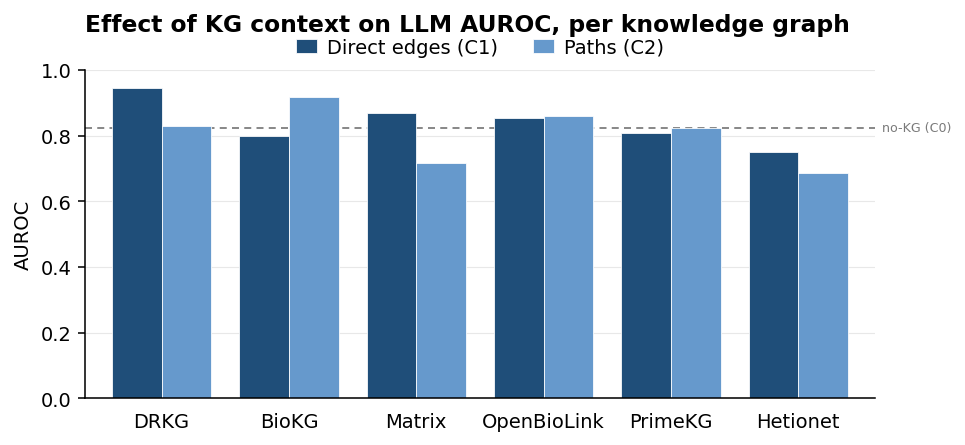

In [ ]:
# ── Effect of KG context on LLM AUROC, per knowledge graph ──────────────
# C0 (no KG) is constant across KGs; C1 (direct edges) and C2 (paths) are per-KG.
C0      = float(auroc_kg['C0_no_kg'].dropna().iloc[0])
COND    = [c for c in ['C1_direct', 'C2_paths'] if c in auroc_kg.columns]
CLABEL  = {'C1_direct': 'Direct edges (C1)', 'C2_paths': 'Paths (C2)'}
CCOLORS = {'C1_direct': '#1f4e79', 'C2_paths': '#6699cc'}
KG_LABEL = {'primekg': 'PrimeKG', 'hetionet': 'Hetionet', 'drkg': 'DRKG',
            'openbilink': 'OpenBioLink', 'biokg': 'BioKG', 'matrix': 'Matrix'}

kgs = sorted(auroc_kg.index, key=lambda k: auroc_kg.loc[k, COND].max(), reverse=True)
x, w = np.arange(len(kgs)), 0.78 / len(COND)

fig, ax = plt.subplots(figsize=(7.0, 3.3))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color='#E8E8E8', lw=0.6, zorder=0)
ax.xaxis.grid(False)
for i, c in enumerate(COND):
    vals = [auroc_kg.loc[k, c] for k in kgs]
    ax.bar(x + (i - (len(COND) - 1) / 2) * w, vals, w,
           color=CCOLORS[c], label=CLABEL[c], edgecolor='white', linewidth=0.4, zorder=2)
ax.axhline(C0, color='#7a7a7a', lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.annotate('no-KG (C0)', xy=(1.0, C0), xycoords=('axes fraction', 'data'),
            xytext=(4, 0), textcoords='offset points', ha='left', va='center',
            fontsize=6.5, color='#7a7a7a', annotation_clip=False)
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_ylabel('AUROC')
ax.set_xticks(x)
ax.set_xlim(-0.6, len(kgs) - 0.4)
ax.tick_params(bottom=False)
ax.set_xticklabels([KG_LABEL.get(k, k) for k in kgs])
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, ncol=len(COND), loc='lower center', bbox_to_anchor=(0.5, 1.01),
          handlelength=1.1, handletextpad=0.5, columnspacing=1.8, borderpad=0)
ax.set_title('Effect of KG context on LLM AUROC, per knowledge graph',
             loc='left', pad=20, fontweight='bold')
fig.tight_layout()
for _ext in ('png', 'pdf'):
    fig.savefig(FIGS / f'09_kg_context_auroc.{_ext}', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()